In [ ]:
!git clone https://github.com/nithinganesh1/Image_Classification.git


Cloning into 'Image_Classification'...
remote: Enumerating objects: 516, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 516 (delta 83), reused 93 (delta 38), pack-reused 343 (from 1)
Receiving objects: 100% (516/516), 110.42 MiB | 23.15 MiB/s, done.
Resolving deltas: 100% (93/93), done.


In [ ]:
cd /content/Image_Classification

/content/Image_Classification


In [ ]:
import tensorflow as tf
import os


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import cv2
import imghdr

/tmp/ipykernel_1991/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [7]:
data_dir = 'data'

In [8]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [10]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)


Image not in ext list data/happy/Readme.md


In [15]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 297 files belonging to 2 classes.


In [12]:
data_iterator = data.as_numpy_iterator()

In [13]:
batch = data_iterator.next()

In [14]:
len(batch)

2

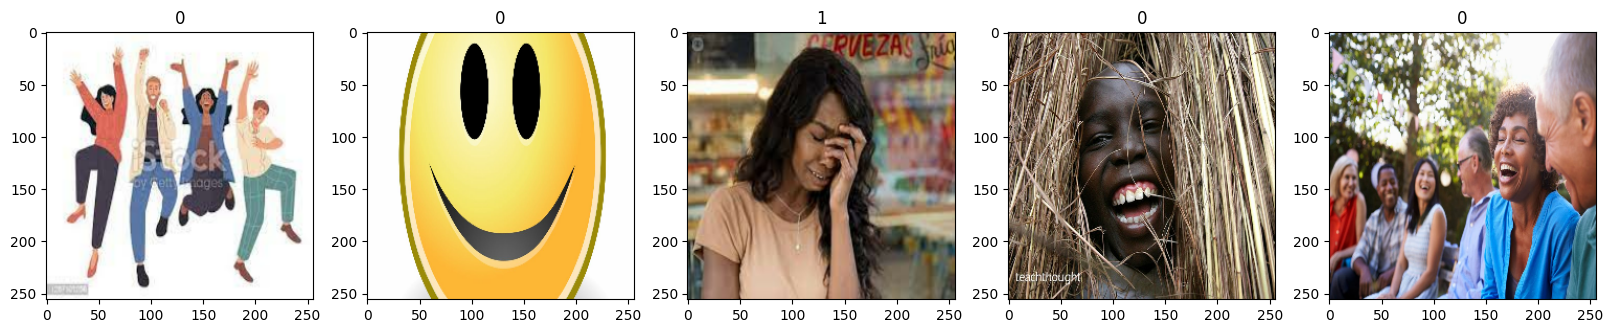

In [16]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [17]:
data = data.map(lambda x,y: (x/255, y))

In [18]:
data.as_numpy_iterator().next()

(array([[[[0.79255515, 0.79255515, 0.8003983 ],
          [0.8003983 , 0.8003983 , 0.8082414 ],
          [0.79686004, 0.79686004, 0.8047032 ],
          ...,
          [0.80143994, 0.7935968 , 0.8053615 ],
          [0.8048407 , 0.79699755, 0.80876225],
          [0.80079955, 0.7929564 , 0.8047211 ]],
 
         [[0.7764706 , 0.7764706 , 0.78431374],
          [0.78431374, 0.78431374, 0.7921569 ],
          [0.7795179 , 0.7795179 , 0.787361  ],
          ...,
          [0.7853554 , 0.77751225, 0.78927696],
          [0.7876801 , 0.77983695, 0.79160166],
          [0.783701  , 0.77585787, 0.7876226 ]],
 
         [[0.78719366, 0.78719366, 0.7950368 ],
          [0.7950368 , 0.7950368 , 0.8028799 ],
          [0.79172796, 0.79172796, 0.7995711 ],
          ...,
          [0.7981464 , 0.7903033 , 0.802068  ],
          [0.7981464 , 0.7903033 , 0.802068  ],
          [0.794424  , 0.78658086, 0.79834557]],
 
         ...,
 
         [[0.56533504, 0.27078846, 0.23756236],
          [0.46293

In [19]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test

In [20]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [21]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [22]:
model = Sequential()

In [23]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
logdir = 'logs'

In [28]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [29]:
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 561ms/step - accuracy: 0.6071 - loss: 0.7101 - val_accuracy: 0.5625 - val_loss: 0.6274
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 708ms/step - accuracy: 0.6875 - loss: 0.5943 - val_accuracy: 0.7812 - val_loss: 0.4912
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 620ms/step - accuracy: 0.7946 - loss: 0.4555 - val_accuracy: 0.7812 - val_loss: 0.3611
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8839 - loss: 0.3213 - val_accuracy: 0.9531 - val_loss: 0.2462
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 540ms/step - accuracy: 0.9375 - loss: 0.2179 - val_accuracy: 0.9531 - val_loss: 0.1584
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 585ms/step - accuracy: 0.9241 - loss: 0.1907 - val_accuracy: 0.9844 - val_loss: 0.1331
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 787ms/step - accuracy: 0.9821 - loss: 0.0878 - val_accuracy: 1.0000 - val_loss: 0.0633
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 577ms/step - accuracy: 0.9598 - loss: 0.1132 - val_accuracy: 0.9844 - val_loss: 0

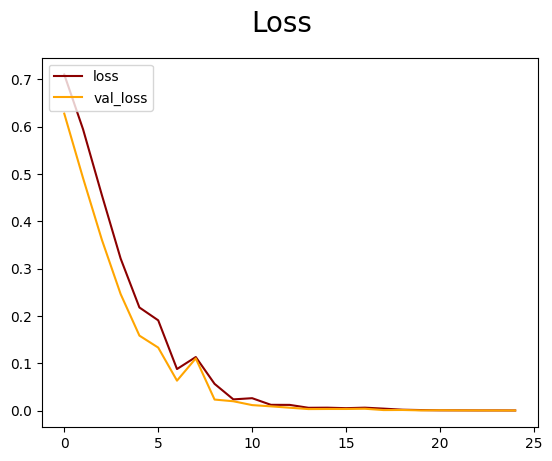

In [31]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()


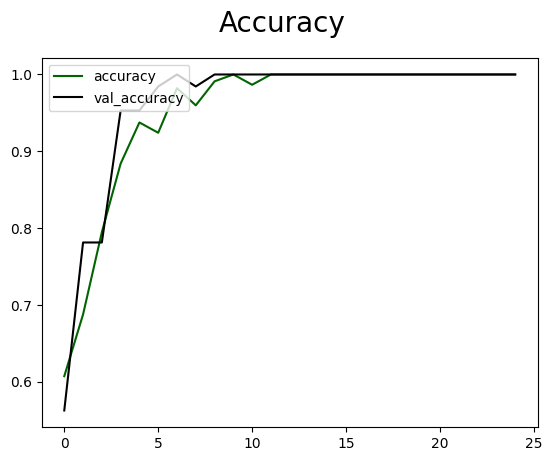

In [32]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [33]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [34]:
Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()

In [35]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step


In [36]:
Pre.result()

<tf.Tensor: shape=(), dtype=float32, numpy=1.0>

In [37]:
print(Re.result())

tf.Tensor(1.0, shape=(), dtype=float32)


In [38]:
print(Acc.result())

tf.Tensor(1.0, shape=(), dtype=float32)


In [39]:
import cv2

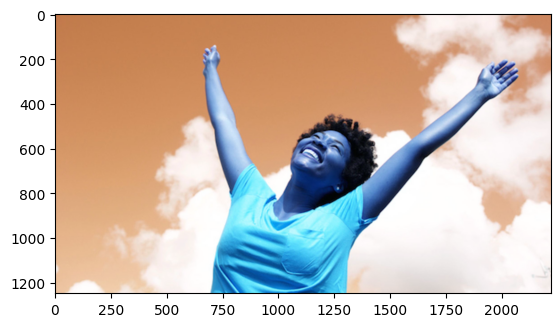

In [40]:
img = cv2.imread('istock-508455188.jpg')
plt.imshow(img)
plt.show()

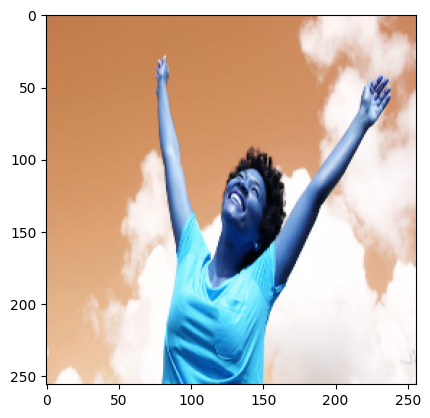

In [41]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [42]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [43]:
yhat

array([[0.00775226]], dtype=float32)

In [45]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


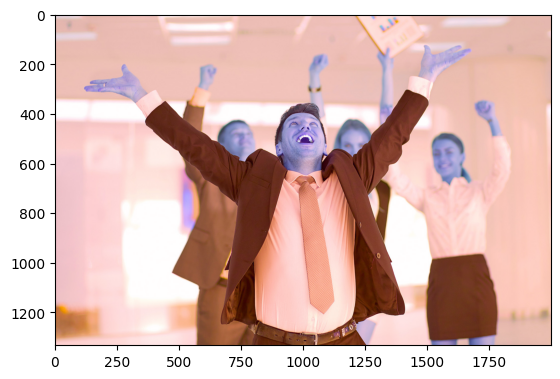

In [71]:
img = cv2.imread('/content/Image_Classification/data/happy/170404-happy-workers-feature.jpg')
plt.imshow(img)
plt.show()

In [77]:
yhat = model.predict(np.expand_dims(resize/255, 0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [76]:
yhat

array([[0.00775226]], dtype=float32)

In [74]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


In [75]:
model.save(os.path.join('models','image_classifier_models.h5'))